In [1]:
import pandas as pd

df = pd.read_csv("UPDATED_FINAL_DATASET.csv")
df.head()

print(df.columns)
print(df["Risk_Category"].value_counts())

Index(['VAERS_ID', 'STATE', 'AGE_YRS', 'SEX', 'NUMDAYS', 'HOSPITAL', 'DIED',
       'L_THREAT', 'DISABLE', 'ER_VISIT', 'ER_ED_VISIT', 'RECOVD', 'HOSPDAYS',
       'Age_Group', 'Severity_Score', 'Risk_Category', 'YEAR',
       'RECOVERY_COMPLEXITY', 'ALL_SYMPTOMS', 'SYMPTOM_CATEGORY'],
      dtype='object')
Risk_Category
Mild        11095
Moderate     1706
Severe        468
Critical       93
Name: count, dtype: int64


In [2]:
X = df.drop(columns=["Risk_Category"])
y = df["Risk_Category"]

In [3]:
print(df.columns)

Index(['VAERS_ID', 'STATE', 'AGE_YRS', 'SEX', 'NUMDAYS', 'HOSPITAL', 'DIED',
       'L_THREAT', 'DISABLE', 'ER_VISIT', 'ER_ED_VISIT', 'RECOVD', 'HOSPDAYS',
       'Age_Group', 'Severity_Score', 'Risk_Category', 'YEAR',
       'RECOVERY_COMPLEXITY', 'ALL_SYMPTOMS', 'SYMPTOM_CATEGORY'],
      dtype='object')


In [4]:
df = df.copy()

# target
y = df["Risk_Category"]

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform(y)

# features
X = df.drop(columns=["Risk_Category"])

#  IMPORTANT FIX
X = pd.get_dummies(X)

# split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [5]:
#Train-test split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [6]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    class_weight="balanced",
    random_state=42
)

rf.fit(X_train, y_train)

from xgboost import XGBClassifier
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(zip(np.unique(y_train), weights))

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    
    eval_metric="mlogloss",
    random_state=42
)
sample_weights = [class_weights[i] for i in y_train]

xgb.fit(X_train, y_train, sample_weight=sample_weights)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

In [7]:
#Evaluation
from sklearn.metrics import classification_report, confusion_matrix

# Random Forest
rf_pred = rf.predict(X_test)

print("RANDOM FOREST")
print(confusion_matrix(y_test, rf_pred))
print(classification_report(y_test, rf_pred))

# XGBoost
xgb_pred = xgb.predict(X_test)

print("\n XGBOOST")
print(confusion_matrix(y_test, xgb_pred))
print(classification_report(y_test, xgb_pred))

RANDOM FOREST
[[  19    0    0    0]
 [   0 2203   16    0]
 [   0   80  261    0]
 [   3    1    3   87]]
              precision    recall  f1-score   support

           0       0.86      1.00      0.93        19
           1       0.96      0.99      0.98      2219
           2       0.93      0.77      0.84       341
           3       1.00      0.93      0.96        94

    accuracy                           0.96      2673
   macro avg       0.94      0.92      0.93      2673
weighted avg       0.96      0.96      0.96      2673


 XGBOOST
[[  19    0    0    0]
 [   0 2219    0    0]
 [   0    0  341    0]
 [   0    0    0   94]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00      2219
           2       1.00      1.00      1.00       341
           3       1.00      1.00      1.00        94

    accuracy                           1.00      2673
   macro avg       1.00      

In [8]:
import joblib

joblib.dump(rf, "rf.pkl")
joblib.dump(xgb, "xgb.pkl")
joblib.dump(le, "label_encoder.pkl")
joblib.dump(X.columns, "feature_columns.pkl")

['feature_columns.pkl']

In [9]:
def predict_sample(model, sample_dict):
    import pandas as pd
    import joblib

    feature_columns = joblib.load("feature_columns.pkl")
    label_encoder = joblib.load("label_encoder.pkl")

    df_input = pd.DataFrame([sample_dict])
    df_input = pd.get_dummies(df_input)
    df_input = df_input.reindex(columns=feature_columns, fill_value=0)

    pred = model.predict(df_input)[0]
    return label_encoder.inverse_transform([pred])[0]


# -----------------------------
# TEST SAMPLES
# -----------------------------
samples = X_test.iloc[:6].to_dict(orient="records")

for i, s in enumerate(samples):
    print(f"\nSample {i+1}")
    print("RF:", predict_sample(rf, s))
    print("XGB:", predict_sample(xgb, s))


Sample 1
RF: Mild
XGB: Mild

Sample 2
RF: Mild
XGB: Mild

Sample 3
RF: Moderate
XGB: Moderate

Sample 4
RF: Mild
XGB: Mild

Sample 5
RF: Mild
XGB: Mild

Sample 6
RF: Mild
XGB: Mild


In [10]:
print(df["Risk_Category"].value_counts())

Risk_Category
Mild        11095
Moderate     1706
Severe        468
Critical       93
Name: count, dtype: int64


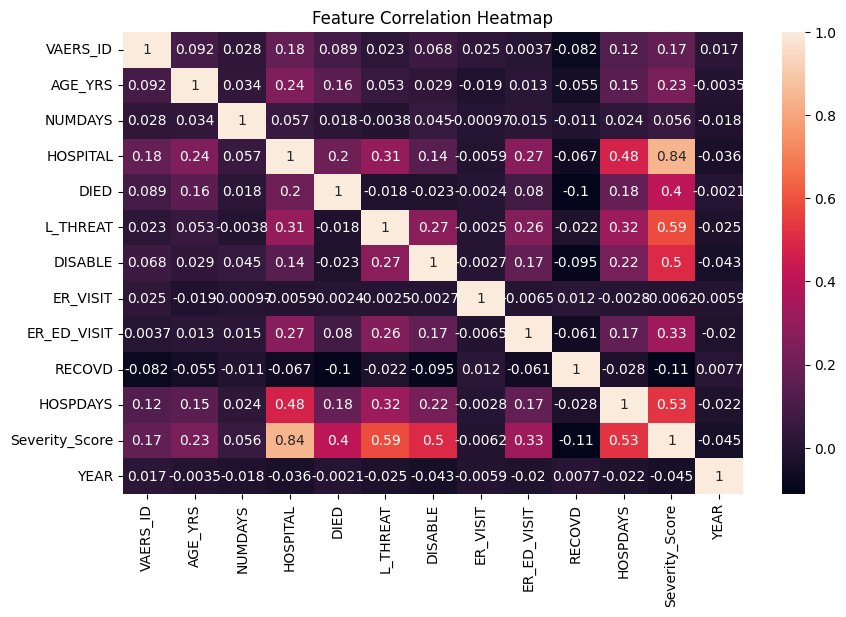

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Feature Correlation Heatmap")
plt.show()

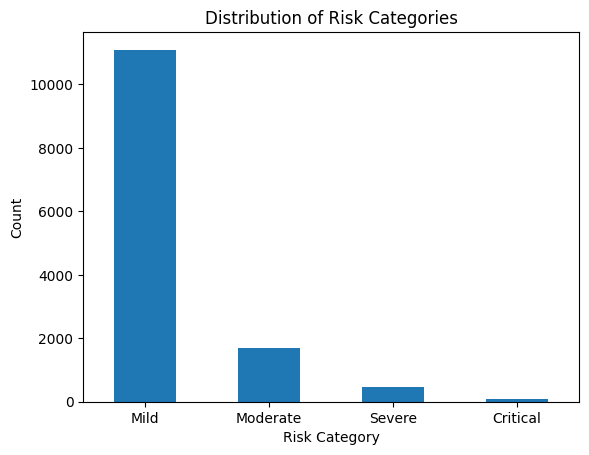

In [12]:
#Risk Category distribution

import matplotlib.pyplot as plt

df["Risk_Category"].value_counts().plot(kind="bar")
plt.title("Distribution of Risk Categories")
plt.xlabel("Risk Category")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

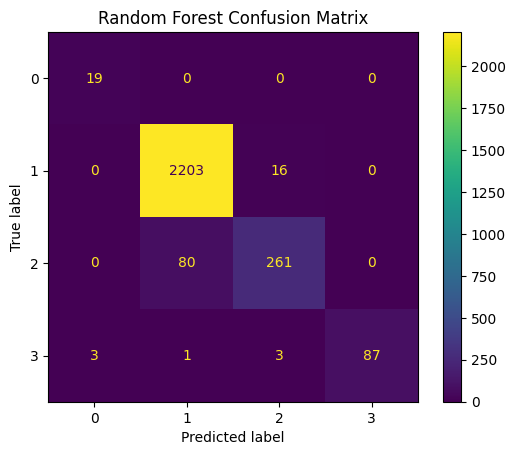

In [13]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(rf, X_test, y_test)
plt.title("Random Forest Confusion Matrix")
plt.show()

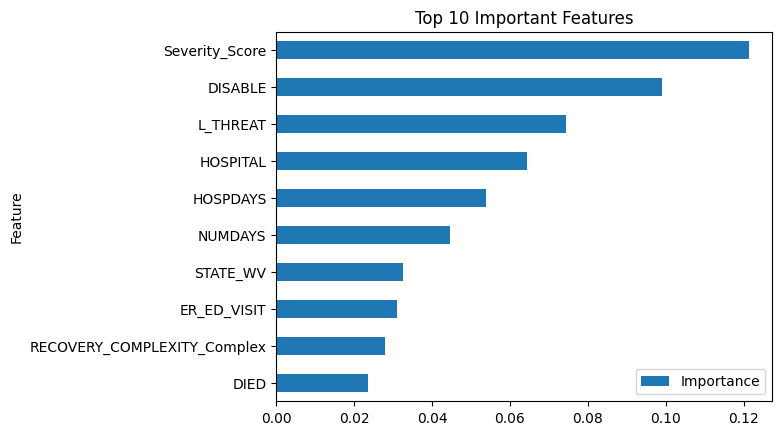

In [14]:
import pandas as pd

importances = rf.feature_importances_
features = X_train.columns

feat_df = pd.DataFrame({
    "Feature": features,
    "Importance": importances
}).sort_values(by="Importance", ascending=False).head(10)

feat_df.plot(kind="barh", x="Feature", y="Importance")
plt.title("Top 10 Important Features")
plt.gca().invert_yaxis()
plt.show()

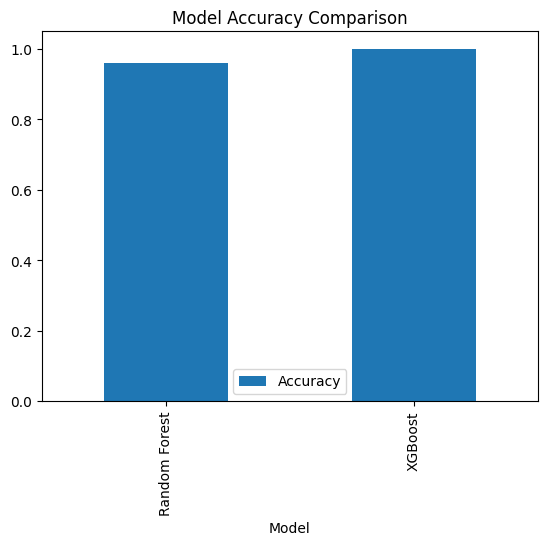

In [15]:
import pandas as pd

data = {
    "Model": ["Random Forest", "XGBoost"],
    "Accuracy": [0.96, 1.00]  # replace if needed
}

df_perf = pd.DataFrame(data)
df_perf.plot(kind="bar", x="Model", y="Accuracy")
plt.title("Model Accuracy Comparison")
plt.show()

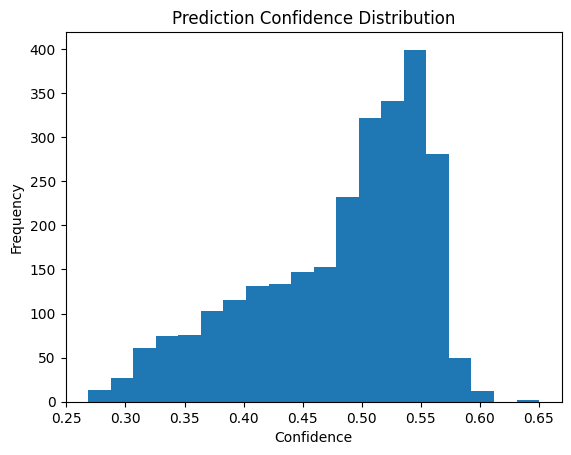

In [16]:
probs = rf.predict_proba(X_test)

import numpy as np

plt.hist(np.max(probs, axis=1), bins=20)
plt.title("Prediction Confidence Distribution")
plt.xlabel("Confidence")
plt.ylabel("Frequency")
plt.show()

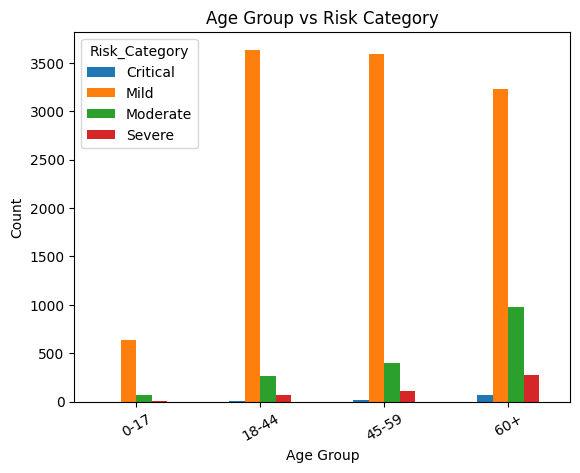

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

age_severity = pd.crosstab(df["Age_Group"], df["Risk_Category"])

age_severity.plot(kind="bar", stacked=False)
plt.title("Age Group vs Risk Category")
plt.xlabel("Age Group")
plt.ylabel("Count")
plt.xticks(rotation=30)
plt.show()

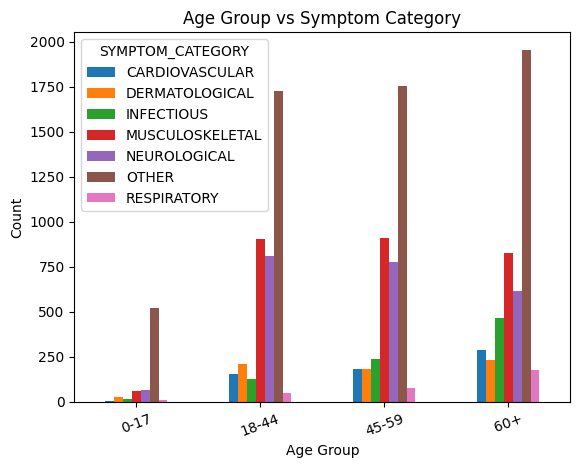

In [18]:
age_symptom = pd.crosstab(df["Age_Group"], df["SYMPTOM_CATEGORY"])

age_symptom.plot(kind="bar", stacked=False)
plt.title("Age Group vs Symptom Category")
plt.xlabel("Age Group")
plt.ylabel("Count")
plt.xticks(rotation=20)
plt.show()

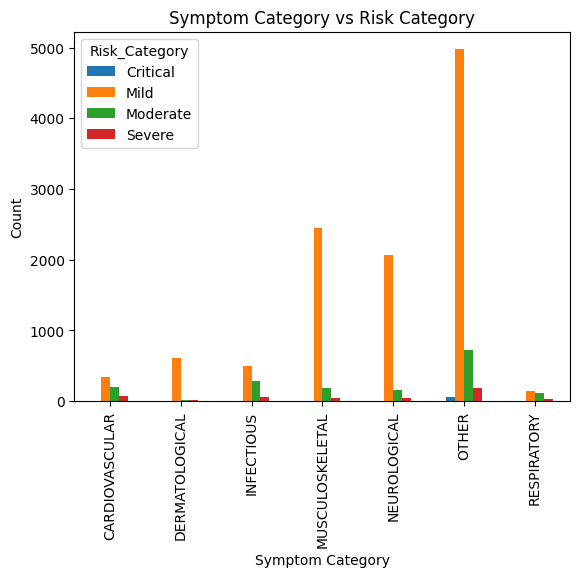

In [19]:
symptom_severity = pd.crosstab(df["SYMPTOM_CATEGORY"], df["Risk_Category"])

symptom_severity.plot(kind="bar", stacked=False)
plt.title("Symptom Category vs Risk Category")
plt.xlabel("Symptom Category")
plt.ylabel("Count")
plt.xticks(rotation=90)
plt.show()

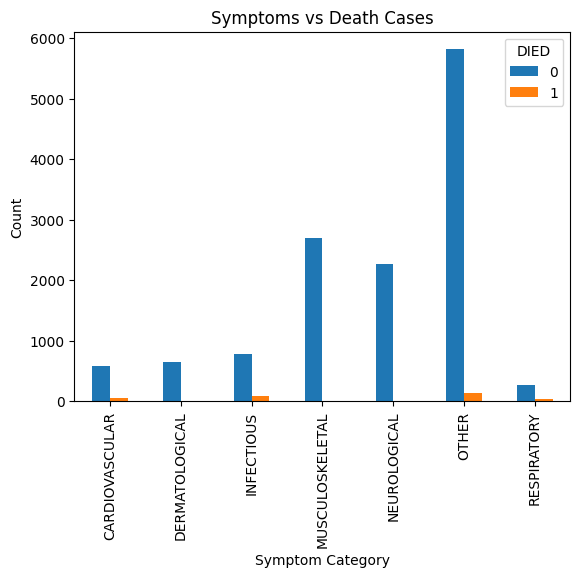

In [20]:
death_symptom = pd.crosstab(df["SYMPTOM_CATEGORY"], df["DIED"])

death_symptom.plot(kind="bar", stacked=False)
plt.title("Symptoms vs Death Cases")
plt.xlabel("Symptom Category")
plt.ylabel("Count")
plt.xticks(rotation=90)
plt.show()

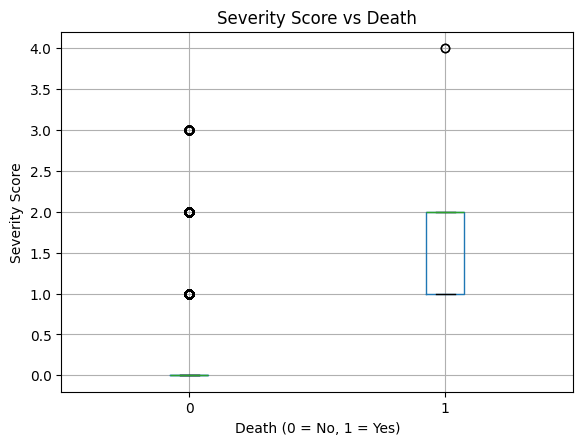

In [21]:
import matplotlib.pyplot as plt

df.boxplot(column="Severity_Score", by="DIED")
plt.title("Severity Score vs Death")
plt.suptitle("")
plt.xlabel("Death (0 = No, 1 = Yes)")
plt.ylabel("Severity Score")
plt.show()

In [22]:
age_risk = pd.crosstab(df["Age_Group"], df["Risk_Category"])

age_risk_percent = pd.crosstab(df["Age_Group"], df["Risk_Category"], normalize='index') * 100

final_table = age_risk.astype(str) + " (" + age_risk_percent.round(1).astype(str) + "%)"

print(final_table)

Risk_Category   Critical          Mild     Moderate      Severe
Age_Group                                                      
0-17            0 (0.0%)   633 (89.5%)    68 (9.6%)    6 (0.8%)
18-44           7 (0.2%)  3637 (91.4%)   265 (6.7%)   70 (1.8%)
45-59          15 (0.4%)  3594 (87.2%)   398 (9.7%)  113 (2.7%)
60+            71 (1.6%)  3231 (70.9%)  975 (21.4%)  279 (6.1%)


In [23]:
symptom_risk = pd.crosstab(df["SYMPTOM_CATEGORY"], df["Risk_Category"])
symptom_risk_percent = pd.crosstab(df["SYMPTOM_CATEGORY"], df["Risk_Category"], normalize='index') * 100

symptom_table = symptom_risk.astype(str) + " (" + symptom_risk_percent.round(1).astype(str) + "%)"

print(symptom_table)

Risk_Category      Critical          Mild     Moderate      Severe
SYMPTOM_CATEGORY                                                  
CARDIOVASCULAR    10 (1.6%)   347 (55.3%)  202 (32.2%)  69 (11.0%)
DERMATOLOGICAL     0 (0.0%)   615 (94.6%)    23 (3.5%)   12 (1.8%)
INFECTIOUS         4 (0.5%)   498 (58.5%)  291 (34.2%)   58 (6.8%)
MUSCULOSKELETAL    9 (0.3%)  2447 (90.6%)   193 (7.1%)   52 (1.9%)
NEUROLOGICAL       7 (0.3%)  2061 (90.6%)   156 (6.9%)   51 (2.2%)
OTHER             63 (1.1%)  4976 (83.6%)  720 (12.1%)  192 (3.2%)
RESPIRATORY        0 (0.0%)   151 (49.3%)  121 (39.5%)  34 (11.1%)


In [24]:
summary = {
    "Total Records": len(df),
    "Average Age": df["AGE_YRS"].mean(),
    "Male": (df["SEX"] == "M").sum(),
    "Female": (df["SEX"] == "F").sum(),
    "Hospitalized": df["HOSPITAL"].sum(),
    "Deaths": df["DIED"].sum()
}

summary_df = pd.DataFrame(summary.items(), columns=["Feature", "Value"])
print(summary_df)

         Feature         Value
0  Total Records  13362.000000
1    Average Age     50.740967
2           Male   4216.000000
3         Female   8681.000000
4   Hospitalized   1812.000000
5         Deaths    327.000000


In [25]:
gender_count = df["SEX"].value_counts()
gender_percent = df["SEX"].value_counts(normalize=True) * 100

gender_table = pd.DataFrame({
    "Count": gender_count,
    "Percentage (%)": gender_percent.round(2)
})

print(gender_table)

     Count  Percentage (%)
SEX                       
F     8681           64.97
M     4216           31.55
U      465            3.48


In [26]:
import pandas as pd

# Create flags (temporary)
covid_flag = df["ALL_SYMPTOMS"].str.contains("covid|corona|sars", case=False, na=False)
booster_flag = df["ALL_SYMPTOMS"].str.contains("booster|dose 3|third dose", case=False, na=False)

# Derive case group (temporary Series)
case_group = pd.Series("Others", index=df.index)

case_group[(booster_flag == True) & (covid_flag == False)] = "Booster Non-COVID"
case_group[covid_flag == True] = "COVID Affected"

# Count + percentage
count = case_group.value_counts()
percent = case_group.value_counts(normalize=True) * 100

# Final table
final_table = pd.DataFrame({
    "N": count,
    "%": percent.round(2)
})


final_table["N (%)"] = final_table["N"].astype(str) + " (" + final_table["%"].astype(str) + "%)"
final_table = final_table[["N (%)"]]

print(final_table)

                         N (%)
Others          11807 (88.36%)
COVID Affected   1555 (11.64%)


In [27]:
death_count = df["DIED"].value_counts()
death_percent = df["DIED"].value_counts(normalize=True) * 100

death_table = pd.DataFrame({
    "Count": death_count,
    "Percentage (%)": death_percent.round(2)
})

print(death_table)

      Count  Percentage (%)
DIED                       
0     13035           97.55
1       327            2.45


In [28]:
gender_risk = pd.crosstab(df["SEX"], df["Risk_Category"])
gender_risk_percent = pd.crosstab(df["SEX"], df["Risk_Category"], normalize='index') * 100

final_gender_risk = gender_risk.astype(str) + " (" + gender_risk_percent.round(1).astype(str) + "%)"

print(final_gender_risk)

Risk_Category   Critical          Mild     Moderate      Severe
SEX                                                            
F              54 (0.6%)  7486 (86.2%)  894 (10.3%)  247 (2.8%)
M              39 (0.9%)  3170 (75.2%)  788 (18.7%)  219 (5.2%)
U               0 (0.0%)   439 (94.4%)    24 (5.2%)    2 (0.4%)


In [29]:
duplicate_count = df.duplicated().sum()

print("Total Duplicate Rows:", duplicate_count)

Total Duplicate Rows: 0


In [30]:
duplicates = df[df.duplicated()]

print(duplicates)

Empty DataFrame
Columns: [VAERS_ID, STATE, AGE_YRS, SEX, NUMDAYS, HOSPITAL, DIED, L_THREAT, DISABLE, ER_VISIT, ER_ED_VISIT, RECOVD, HOSPDAYS, Age_Group, Severity_Score, Risk_Category, YEAR, RECOVERY_COMPLEXITY, ALL_SYMPTOMS, SYMPTOM_CATEGORY]
Index: []


In [31]:
duplicate_percent = (df.duplicated().sum() / len(df)) * 100

print("Duplicate %:", round(duplicate_percent, 2))

Duplicate %: 0.0
